In [1]:
# ——————————————————————————————————————————————————
# IMPORTS
# ——————————————————————————————————————————————————
import pandas as pd
import arff
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ——————————————————————————————————————————————————
# DATA LOADING
# ——————————————————————————————————————————————————
with open("data/house_dataset.arff", "r") as f:
    dataset = arff.load(f)


df = pd.DataFrame(
    dataset["data"],
    columns=[attr[0] for attr in dataset["attributes"]],
)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [8]:
# ——————————————————————————————————————————————————
# BASIC INSPECTION
# ——————————————————————————————————————————————————
# df.shape
# print(df.info())
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>, <Axes: >]],
      dtype=object)

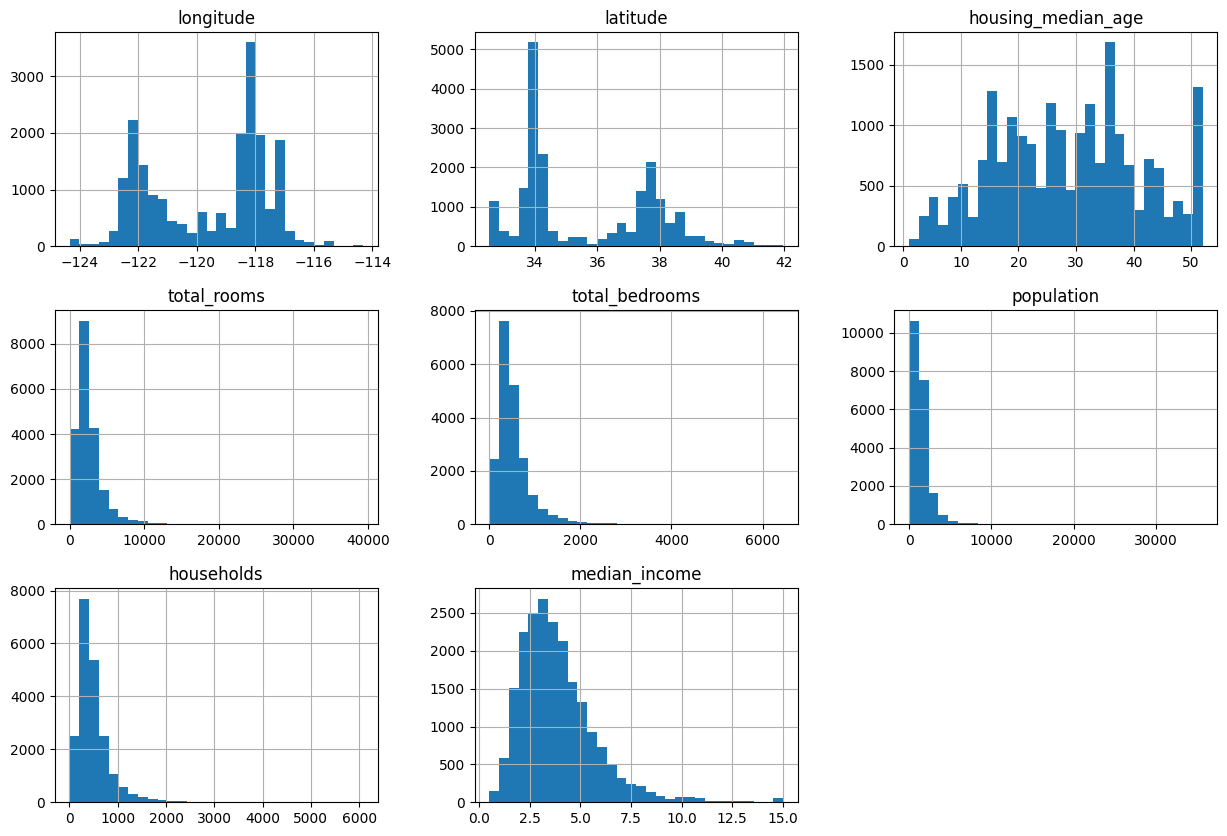

In [9]:
# ——————————————————————————————————————————————————
# VARIABLES DISTRIBUTION
# ——————————————————————————————————————————————————

df_no_target = df.drop(columns=["median_house_value"])
df_no_target.hist(
    figsize=(15, 10),
    bins=30
)

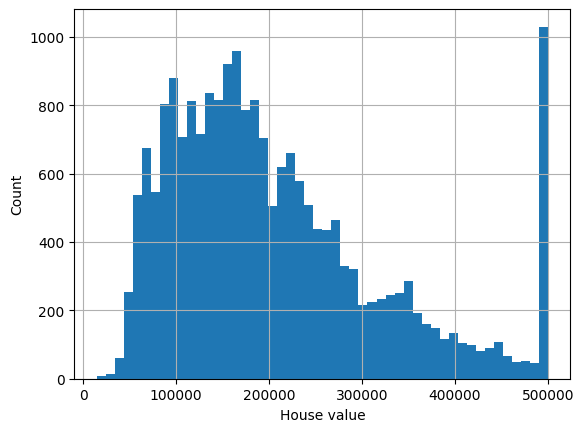

In [10]:
# ——————————————————————————————————————————————————
# TARGET ANALYSIS
# ——————————————————————————————————————————————————

df["median_house_value"].hist(
    bins=50,
)

plt.xlabel("House value")
plt.ylabel("Count")
plt.show()

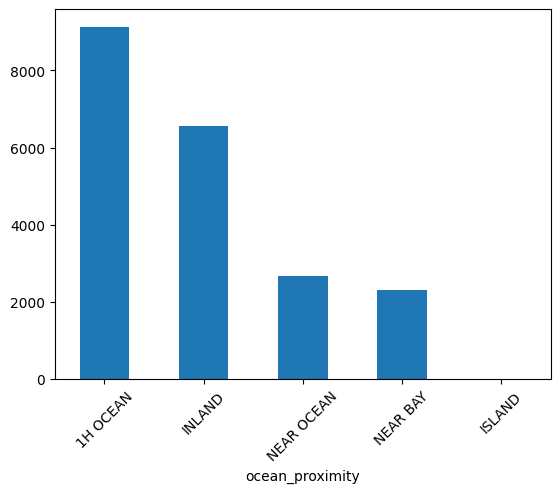

In [11]:
# ——————————————————————————————————————————————————
# CATEGORICAL ANALYSIS|
# ——————————————————————————————————————————————————
df["ocean_proximity"].value_counts().plot(
    kind="bar"
)

plt.xticks(rotation=45)
plt.show()

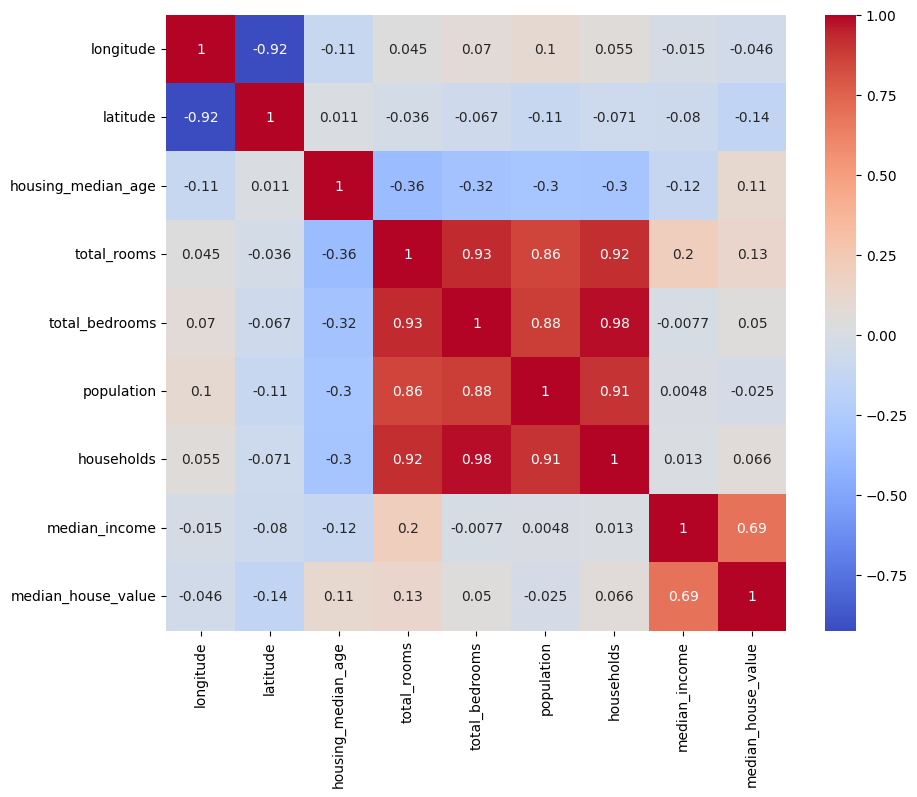

In [12]:
# ——————————————————————————————————————————————————
# CORRELATION ANALYSIS
# ——————————————————————————————————————————————————
corr = df.select_dtypes(
    include="number"
).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
)

plt.show()

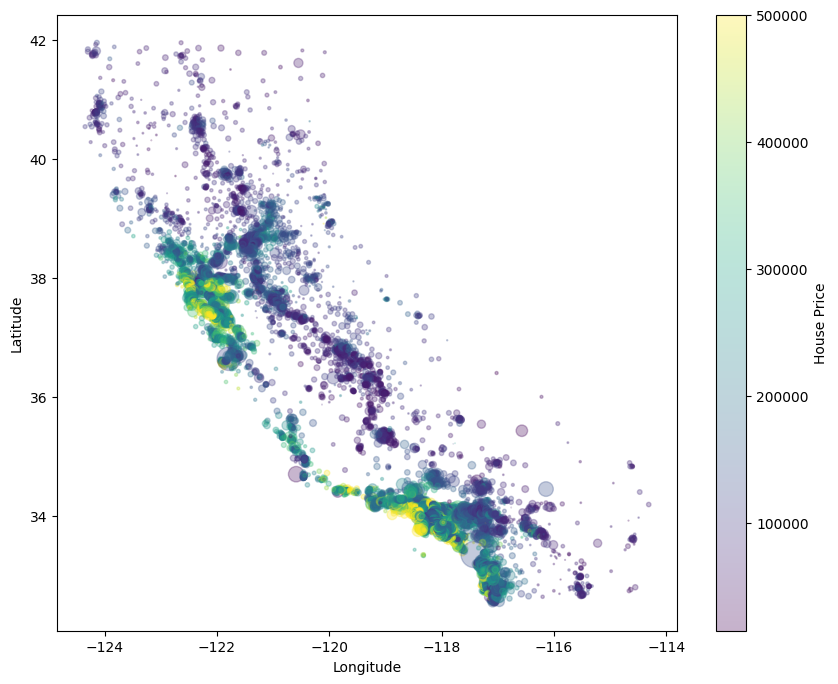

In [13]:
# ——————————————————————————————————————————————————
# Spatial Visualization
# ——————————————————————————————————————————————————
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.3,
    c=df["median_house_value"],
    s=df["population"]/100,
)

plt.colorbar(
    label="House Price"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

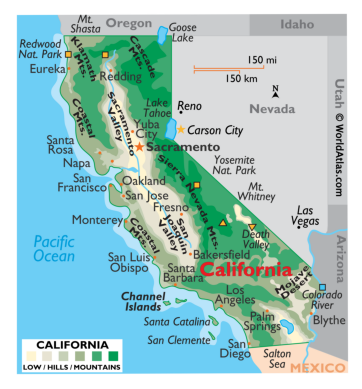

In [15]:
import matplotlib.image as mpimg
img = mpimg.imread('cali.png')

plt.imshow(img)
plt.axis('off')  # opcional, oculta los ejes
plt.show()